In [1]:
# Cell 001: Project title and execution note
PROJECT_TITLE = "DocRank360: Bi-Encoder + Cross-Encoder Document Ranking"
print(PROJECT_TITLE)
print("Goal: synthetic validation first, then real public data through the same ranking pipeline.")


DocRank360: Bi-Encoder + Cross-Encoder Document Ranking
Goal: synthetic validation first, then real public data through the same ranking pipeline.


In [2]:
# Cell 002: Core imports
import os, re, json, time, random, zipfile, ast
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import pandas as pd


In [3]:
# Cell 003: Optional visualization imports
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [4]:
# Cell 004: Optional public dataset import
try:
    from datasets import load_dataset
    HAS_DATASETS = True
except Exception:
    load_dataset = None
    HAS_DATASETS = False
print("datasets available:", HAS_DATASETS)


datasets available: True


In [5]:
# Cell 005: Optional transformer ranking imports
try:
    from sentence_transformers import SentenceTransformer, CrossEncoder
    HAS_SENTENCE_TRANSFORMERS = True
except Exception:
    SentenceTransformer = None
    CrossEncoder = None
    HAS_SENTENCE_TRANSFORMERS = False
print("sentence-transformers available:", HAS_SENTENCE_TRANSFORMERS)



sentence-transformers available: True


In [6]:
# Cell 006: Scikit-learn fallback imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [7]:
# Cell 007: Global reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Seed:", SEED)


Seed: 42


In [8]:
# Cell 008: Project configuration
CONFIG = {
    "project_name": "DocRank360",
    "synthetic_docs": 80,
    "synthetic_queries": 45,
    "real_examples": 120,
    "bi_top_k": 10,
    "rerank_top_n": 5,
    "bi_encoder_model": "sentence-transformers/all-MiniLM-L6-v2",
    "cross_encoder_model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
}
CONFIG


{'project_name': 'DocRank360',
 'synthetic_docs': 80,
 'synthetic_queries': 45,
 'real_examples': 120,
 'bi_top_k': 10,
 'rerank_top_n': 5,
 'bi_encoder_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'cross_encoder_model': 'cross-encoder/ms-marco-MiniLM-L-6-v2'}

In [9]:
# Cell 009: Output directory setup
OUTPUT_ROOT = Path("outputs")
OUTPUT_ROOT.mkdir(exist_ok=True)
PROJECT_OUTPUT_DIR = OUTPUT_ROOT / "document_ranking_project"
PROJECT_OUTPUT_DIR.mkdir(exist_ok=True)
print(PROJECT_OUTPUT_DIR.resolve())


C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Transformer\Cross-Encoder vs Bi-Encoder Ranking System\outputs\document_ranking_project


In [10]:
# Cell 010: Timed context manager
from contextlib import contextmanager
@contextmanager
def timed(label: str):
    t0 = time.perf_counter()
    yield
    dt = time.perf_counter() - t0
    print(f"{label} completed in {dt:.3f}s")


In [11]:
# Cell 011: Text normalization utility
def normalize_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    return text.strip()


In [12]:
# Cell 012: Tokenizer utility
def tokenize(text: Any) -> List[str]:
    return re.findall(r"[A-Za-z0-9_\-]+", normalize_text(text).lower())


In [13]:
# Cell 013: Slug utility
def safe_slug(text: Any, max_len: int = 60) -> str:
    value = re.sub(r"[^A-Za-z0-9]+", "_", normalize_text(text))
    value = value.strip("_")[:max_len]
    return value or "item"


In [14]:
# Cell 014: Data classes
@dataclass
class DocumentRecord:
    doc_id: str
    title: str
    text: str
    source_type: str
    metadata: Optional[Dict[str, Any]] = None

@dataclass
class QueryRecord:
    query_id: str
    query: str
    relevant_doc_ids: List[str]
    answer: str
    source_type: str
    metadata: Optional[Dict[str, Any]] = None


In [15]:
# Cell 015: DataFrame display helper
def show_df(df: pd.DataFrame, n: int = 5):
    if df is None or len(df) == 0:
        print("Empty DataFrame")
        return pd.DataFrame()
    display(df.head(n))
    return df.head(n)


In [16]:
# Cell 016: Build synthetic domain lists
SYN_DOMAINS = ["quality analytics", "supply chain", "predictive maintenance", "customer support", "manufacturing yield"]
SYN_TOOLS = ["FAISS", "Power BI", "SQL Server", "Azure ML", "Python", "Streamlit"]
SYN_RISKS = ["latency drift", "data leakage", "sensor noise", "missing values", "class imbalance"]
print(len(SYN_DOMAINS), len(SYN_TOOLS), len(SYN_RISKS))


5 6 5


In [17]:
# Cell 017: Synthetic document builder
def build_synthetic_corpus(n_docs: int = 80, n_queries: int = 45) -> Tuple[List[DocumentRecord], List[QueryRecord]]:
    docs: List[DocumentRecord] = []
    queries: List[QueryRecord] = []
    for i in range(n_docs):
        domain = random.choice(SYN_DOMAINS)
        tool = random.choice(SYN_TOOLS)
        risk = random.choice(SYN_RISKS)
        title = f"{domain.title()} playbook using {tool}"
        text = (
            f"This document explains how a team used {tool} for {domain}. "
            f"It describes data ingestion, preprocessing, ranking, monitoring, and evaluation. "
            f"The primary risk discussed is {risk}. "
            f"The recommended mitigation is validation checks, logging, and metric review."
        )
        docs.append(DocumentRecord(
            doc_id=f"SYN_DOC_{i:04d}",
            title=title,
            text=text,
            source_type="synthetic",
            metadata={"domain": domain, "tool": tool, "risk": risk},
        ))
    eligible = random.sample(docs, min(n_queries, len(docs)))
    for j, doc in enumerate(eligible):
        md = doc.metadata or {}
        query = f"Which document explains {md.get('domain')} with {md.get('tool')} and discusses {md.get('risk')}?"
        queries.append(QueryRecord(
            query_id=f"SYN_Q_{j:04d}",
            query=query,
            relevant_doc_ids=[doc.doc_id],
            answer=doc.title,
            source_type="synthetic",
            metadata={"target_title": doc.title},
        ))
    return docs, queries


In [18]:
# Cell 018: Create synthetic dataset
with timed("Build synthetic dataset"):
    synthetic_docs, synthetic_queries = build_synthetic_corpus(CONFIG["synthetic_docs"], CONFIG["synthetic_queries"])
print(len(synthetic_docs), len(synthetic_queries))


Build synthetic dataset completed in 0.000s
80 45


In [19]:
# Cell 019: Synthetic corpus DataFrame
synthetic_docs_df = pd.DataFrame([asdict(d) for d in synthetic_docs])
show_df(synthetic_docs_df, 3)


,doc_id,title,text,source_type,metadata
0,SYN_DOC_0000,Quality Analytics playbook using FAISS,This document explains how a team used FAISS f...,synthetic,"{'domain': 'quality analytics', 'tool': 'FAISS..."
1,SYN_DOC_0001,Supply Chain playbook using Power BI,This document explains how a team used Power B...,synthetic,"{'domain': 'supply chain', 'tool': 'Power BI',..."
2,SYN_DOC_0002,Quality Analytics playbook using Streamlit,This document explains how a team used Streaml...,synthetic,"{'domain': 'quality analytics', 'tool': 'Strea..."


,doc_id,title,text,source_type,metadata
0,SYN_DOC_0000,Quality Analytics playbook using FAISS,This document explains how a team used FAISS f...,synthetic,"{'domain': 'quality analytics', 'tool': 'FAISS..."
1,SYN_DOC_0001,Supply Chain playbook using Power BI,This document explains how a team used Power B...,synthetic,"{'domain': 'supply chain', 'tool': 'Power BI',..."
2,SYN_DOC_0002,Quality Analytics playbook using Streamlit,This document explains how a team used Streaml...,synthetic,"{'domain': 'quality analytics', 'tool': 'Strea..."


In [20]:
# Cell 020: Synthetic query DataFrame
synthetic_queries_df = pd.DataFrame([asdict(q) for q in synthetic_queries])
show_df(synthetic_queries_df, 3)


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,SYN_Q_0000,Which document explains manufacturing yield wi...,[SYN_DOC_0055],Manufacturing Yield playbook using Python,synthetic,{'target_title': 'Manufacturing Yield playbook...
1,SYN_Q_0001,Which document explains customer support with ...,[SYN_DOC_0045],Customer Support playbook using Python,synthetic,{'target_title': 'Customer Support playbook us...
2,SYN_Q_0002,Which document explains supply chain with SQL ...,[SYN_DOC_0054],Supply Chain playbook using SQL Server,synthetic,{'target_title': 'Supply Chain playbook using ...


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,SYN_Q_0000,Which document explains manufacturing yield wi...,[SYN_DOC_0055],Manufacturing Yield playbook using Python,synthetic,{'target_title': 'Manufacturing Yield playbook...
1,SYN_Q_0001,Which document explains customer support with ...,[SYN_DOC_0045],Customer Support playbook using Python,synthetic,{'target_title': 'Customer Support playbook us...
2,SYN_Q_0002,Which document explains supply chain with SQL ...,[SYN_DOC_0054],Supply Chain playbook using SQL Server,synthetic,{'target_title': 'Supply Chain playbook using ...


In [21]:
# Cell 021: Synthetic source validation
print(synthetic_docs_df["source_type"].value_counts())


source_type
synthetic    80
Name: count, dtype: int64


In [22]:
# Cell 022: Synthetic query validation
print(synthetic_queries_df["source_type"].value_counts())


source_type
synthetic    45
Name: count, dtype: int64


In [23]:
# Cell 023: Real dataset parser for SQuAD rows
def _parse_squad_row(row: Dict[str, Any], idx: int) -> Tuple[Optional[DocumentRecord], Optional[QueryRecord]]:
    title = normalize_text(row.get("title", f"SQuAD article {idx}"))
    context = normalize_text(row.get("context", ""))
    question = normalize_text(row.get("question", ""))
    answers = row.get("answers", {})
    answer_text = ""
    if isinstance(answers, dict):
        vals = answers.get("text", [])
        answer_text = normalize_text(vals[0]) if vals else ""
    if not context or not question:
        return None, None
    doc_id = f"REAL_SQUAD_{idx:05d}_{safe_slug(title, 35)}"
    doc = DocumentRecord(doc_id=doc_id, title=title, text=context, source_type="real_squad", metadata={"dataset": "squad"})
    query = QueryRecord(query_id=f"REAL_Q_{idx:05d}", query=question, relevant_doc_ids=[doc_id], answer=answer_text, source_type="real_squad", metadata={"title": title})
    return doc, query


In [24]:
# Cell 024: Real public dataset loader with robust fallback
def load_real_public_dataset(max_examples: int = 120) -> Tuple[List[DocumentRecord], List[QueryRecord], str]:
    if not HAS_DATASETS:
        return [], [], "datasets_not_installed"
    attempts = [
        ("squad", None, f"validation[:{max_examples}]"),
        ("squad", None, f"train[:{max_examples}]"),
    ]
    last_error = None
    for name, subset, split in attempts:
        try:
            ds = load_dataset(name, split=split) if subset is None else load_dataset(name, subset, split=split)
            docs, queries = [], []
            seen = set()
            for idx, row in enumerate(ds):
                doc, query = _parse_squad_row(row, idx)
                if doc is None or query is None:
                    continue
                if doc.doc_id not in seen:
                    docs.append(doc)
                    seen.add(doc.doc_id)
                queries.append(query)
            if docs and queries:
                return docs, queries, f"{name}:{split}"
        except Exception as exc:
            last_error = exc
    return [], [], f"failed:{type(last_error).__name__ if last_error else 'unknown'}"


In [25]:
# Cell 025: Load real public ranking data
with timed("Load real public data"):
    real_docs, real_queries, real_status = load_real_public_dataset(CONFIG["real_examples"])
print("Real status:", real_status)
print("Real docs:", len(real_docs), "Real queries:", len(real_queries))


Load real public data completed in 11.720s
Real status: squad:validation[:120]
Real docs: 120 Real queries: 120


In [26]:
# Cell 026: Real docs DataFrame
real_docs_df = pd.DataFrame([asdict(d) for d in real_docs])
show_df(real_docs_df, 3)


,doc_id,title,text,source_type,metadata
0,REAL_SQUAD_00000_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}
1,REAL_SQUAD_00001_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}
2,REAL_SQUAD_00002_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}


,doc_id,title,text,source_type,metadata
0,REAL_SQUAD_00000_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}
1,REAL_SQUAD_00001_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}
2,REAL_SQUAD_00002_Super_Bowl_50,Super_Bowl_50,Super Bowl 50 was an American football game to...,real_squad,{'dataset': 'squad'}


In [27]:
# Cell 027: Real queries DataFrame
real_queries_df = pd.DataFrame([asdict(q) for q in real_queries])
show_df(real_queries_df, 3)


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,REAL_Q_00000,Which NFL team represented the AFC at Super Bo...,[REAL_SQUAD_00000_Super_Bowl_50],Denver Broncos,real_squad,{'title': 'Super_Bowl_50'}
1,REAL_Q_00001,Which NFL team represented the NFC at Super Bo...,[REAL_SQUAD_00001_Super_Bowl_50],Carolina Panthers,real_squad,{'title': 'Super_Bowl_50'}
2,REAL_Q_00002,Where did Super Bowl 50 take place?,[REAL_SQUAD_00002_Super_Bowl_50],"Santa Clara, California",real_squad,{'title': 'Super_Bowl_50'}


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,REAL_Q_00000,Which NFL team represented the AFC at Super Bo...,[REAL_SQUAD_00000_Super_Bowl_50],Denver Broncos,real_squad,{'title': 'Super_Bowl_50'}
1,REAL_Q_00001,Which NFL team represented the NFC at Super Bo...,[REAL_SQUAD_00001_Super_Bowl_50],Carolina Panthers,real_squad,{'title': 'Super_Bowl_50'}
2,REAL_Q_00002,Where did Super Bowl 50 take place?,[REAL_SQUAD_00002_Super_Bowl_50],"Santa Clara, California",real_squad,{'title': 'Super_Bowl_50'}


In [28]:
# Cell 028: Real-data validation flag
REAL_DATA_AVAILABLE = len(real_docs) > 0 and len(real_queries) > 0
print("REAL_DATA_AVAILABLE:", REAL_DATA_AVAILABLE)
print("real_status:", real_status)


REAL_DATA_AVAILABLE: True
real_status: squad:validation[:120]


In [29]:
# Cell 029: Unified corpus builder
def build_unified_corpus(syn_docs: List[DocumentRecord], syn_queries: List[QueryRecord],
                         real_docs: List[DocumentRecord], real_queries: List[QueryRecord]) -> Tuple[List[DocumentRecord], List[QueryRecord]]:
    docs = list(syn_docs)
    queries = list(syn_queries)
    if real_docs and real_queries:
        docs.extend(real_docs)
        queries.extend(real_queries)
    return docs, queries


In [30]:
# Cell 030: Build unified corpus
unified_docs, unified_queries = build_unified_corpus(synthetic_docs, synthetic_queries, real_docs, real_queries)
print("Unified docs:", len(unified_docs))
print("Unified queries:", len(unified_queries))


Unified docs: 200
Unified queries: 165


In [31]:
# Cell 031: Unified corpus DataFrame
corpus_df = pd.DataFrame([asdict(d) for d in unified_docs])
show_df(corpus_df, 3)


,doc_id,title,text,source_type,metadata
0,SYN_DOC_0000,Quality Analytics playbook using FAISS,This document explains how a team used FAISS f...,synthetic,"{'domain': 'quality analytics', 'tool': 'FAISS..."
1,SYN_DOC_0001,Supply Chain playbook using Power BI,This document explains how a team used Power B...,synthetic,"{'domain': 'supply chain', 'tool': 'Power BI',..."
2,SYN_DOC_0002,Quality Analytics playbook using Streamlit,This document explains how a team used Streaml...,synthetic,"{'domain': 'quality analytics', 'tool': 'Strea..."


,doc_id,title,text,source_type,metadata
0,SYN_DOC_0000,Quality Analytics playbook using FAISS,This document explains how a team used FAISS f...,synthetic,"{'domain': 'quality analytics', 'tool': 'FAISS..."
1,SYN_DOC_0001,Supply Chain playbook using Power BI,This document explains how a team used Power B...,synthetic,"{'domain': 'supply chain', 'tool': 'Power BI',..."
2,SYN_DOC_0002,Quality Analytics playbook using Streamlit,This document explains how a team used Streaml...,synthetic,"{'domain': 'quality analytics', 'tool': 'Strea..."


In [32]:
# Cell 032: Unified query DataFrame
queries_df = pd.DataFrame([asdict(q) for q in unified_queries])
show_df(queries_df, 3)


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,SYN_Q_0000,Which document explains manufacturing yield wi...,[SYN_DOC_0055],Manufacturing Yield playbook using Python,synthetic,{'target_title': 'Manufacturing Yield playbook...
1,SYN_Q_0001,Which document explains customer support with ...,[SYN_DOC_0045],Customer Support playbook using Python,synthetic,{'target_title': 'Customer Support playbook us...
2,SYN_Q_0002,Which document explains supply chain with SQL ...,[SYN_DOC_0054],Supply Chain playbook using SQL Server,synthetic,{'target_title': 'Supply Chain playbook using ...


,query_id,query,relevant_doc_ids,answer,source_type,metadata
0,SYN_Q_0000,Which document explains manufacturing yield wi...,[SYN_DOC_0055],Manufacturing Yield playbook using Python,synthetic,{'target_title': 'Manufacturing Yield playbook...
1,SYN_Q_0001,Which document explains customer support with ...,[SYN_DOC_0045],Customer Support playbook using Python,synthetic,{'target_title': 'Customer Support playbook us...
2,SYN_Q_0002,Which document explains supply chain with SQL ...,[SYN_DOC_0054],Supply Chain playbook using SQL Server,synthetic,{'target_title': 'Supply Chain playbook using ...


In [33]:
# Cell 033: Verify synthetic + real source counts
print(corpus_df["source_type"].value_counts())
print(queries_df["source_type"].value_counts())


source_type
real_squad    120
synthetic      80
Name: count, dtype: int64
source_type
real_squad    120
synthetic      45
Name: count, dtype: int64


In [34]:
# Cell 034: Bi-encoder backend
class BiEncoderBackend:
    def __init__(self, model_name: str):
        self.backend = "tfidf"
        self.model = None
        self.vectorizer = None
        if HAS_SENTENCE_TRANSFORMERS:
            try:
                self.model = SentenceTransformer(model_name)
                self.backend = "sentence_transformer"
            except Exception as exc:
                print("SentenceTransformer fallback to TF-IDF:", exc)
                self.model = None
        if self.backend == "tfidf":
            self.vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")

    def fit(self, texts: List[str]) -> None:
        if self.backend == "tfidf":
            self.vectorizer.fit(texts)

    def encode(self, texts: List[str]) -> np.ndarray:
        texts = [normalize_text(x) for x in texts]
        if self.backend == "sentence_transformer":
            arr = self.model.encode(texts, batch_size=32, show_progress_bar=False, normalize_embeddings=True)
            return np.asarray(arr, dtype="float32")
        arr = self.vectorizer.transform(texts).astype(np.float32).toarray()
        norms = np.linalg.norm(arr, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return arr / norms


In [35]:
# Cell 035: Cross-encoder reranker backend
class CrossEncoderReranker:
    def __init__(self, model_name: str):
        self.backend = "lexical"
        self.model = None
        if HAS_SENTENCE_TRANSFORMERS:
            try:
                self.model = CrossEncoder(model_name)
                self.backend = "cross_encoder"
            except Exception as exc:
                print("CrossEncoder fallback to lexical:", exc)
                self.model = None

    def score(self, query: str, docs: List[str]) -> np.ndarray:
        query = normalize_text(query)
        docs = [normalize_text(x) for x in docs]
        if not docs:
            return np.array([], dtype=float)
        if self.backend == "cross_encoder":
            pairs = [[query, doc] for doc in docs]
            scores = self.model.predict(pairs)
            return np.asarray(scores, dtype=float)
        q_tokens = set(tokenize(query))
        scores = []
        for doc in docs:
            d_tokens = set(tokenize(doc))
            overlap = len(q_tokens & d_tokens) / max(len(q_tokens), 1)
            phrase_bonus = 0.15 if query.lower() in doc.lower() else 0.0
            scores.append(overlap + phrase_bonus)
        return np.asarray(scores, dtype=float)


In [36]:
# Cell 036: Unified ranker class
class UnifiedRanker:
    def __init__(self, docs: List[DocumentRecord]):
        self.docs = docs
        self.doc_df = pd.DataFrame([asdict(d) for d in docs])
        self.bi_encoder = BiEncoderBackend(CONFIG["bi_encoder_model"])
        self.cross_encoder = CrossEncoderReranker(CONFIG["cross_encoder_model"])
        self.ready = False
        if len(self.doc_df):
            self._fit()

    def _fit(self) -> None:
        self.doc_df["search_text"] = (
            self.doc_df["title"].fillna("").astype(str) + " " +
            self.doc_df["text"].fillna("").astype(str)
        ).map(normalize_text)
        texts = self.doc_df["search_text"].tolist()
        self.bi_encoder.fit(texts)
        self.doc_embeddings = self.bi_encoder.encode(texts).astype("float32")
        self.ready = True

    def retrieve(self, query: str, top_k: int = 10) -> pd.DataFrame:
        if not self.ready or len(self.doc_df) == 0:
            return pd.DataFrame()
        q_emb = self.bi_encoder.encode([query]).astype("float32")[0]
        scores = (self.doc_embeddings @ q_emb).ravel()
        k = min(top_k, len(scores))
        idxs = np.argsort(scores)[::-1][:k]
        out = self.doc_df.iloc[idxs].copy()
        out["bi_score"] = scores[idxs]
        return out

    def rerank(self, query: str, candidates: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
        if candidates is None or len(candidates) == 0:
            return pd.DataFrame()
        out = candidates.copy()
        docs = out["search_text"].fillna("").astype(str).tolist()
        out["cross_score"] = self.cross_encoder.score(query, docs)
        out["rank_score"] = 0.35 * out["bi_score"].astype(float) + 0.65 * out["cross_score"].astype(float)
        return out.sort_values("rank_score", ascending=False).head(top_n).copy()

    def search(self, query: str, top_k: int = 10, rerank_top_n: int = 5) -> pd.DataFrame:
        candidates = self.retrieve(query, top_k=top_k)
        return self.rerank(query, candidates, top_n=rerank_top_n)


In [37]:
# Cell 037: Build synthetic-only ranker
with timed("Build synthetic-only ranker"):
    synthetic_ranker = UnifiedRanker(synthetic_docs)
print("Bi backend:", synthetic_ranker.bi_encoder.backend)
print("Cross backend:", synthetic_ranker.cross_encoder.backend)


Build synthetic-only ranker completed in 25.152s
Bi backend: sentence_transformer
Cross backend: cross_encoder


In [38]:
# Cell 038: Build unified synthetic + real ranker
with timed("Build unified ranker"):
    unified_ranker = UnifiedRanker(unified_docs)
print("Bi backend:", unified_ranker.bi_encoder.backend)
print("Cross backend:", unified_ranker.cross_encoder.backend)


Build unified ranker completed in 32.080s
Bi backend: sentence_transformer
Cross backend: cross_encoder


In [39]:
# Cell 039: Ranking metric hit@k
def hit_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    return float(bool(set(retrieved_ids[:k]) & set(relevant_ids)))


In [40]:
# Cell 040: Ranking metric reciprocal rank
def reciprocal_rank(retrieved_ids: List[str], relevant_ids: List[str]) -> float:
    relevant = set(relevant_ids)
    for idx, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant:
            return 1.0 / idx
    return 0.0


In [41]:
# Cell 041: Evaluation function
def evaluate_ranker(ranker: UnifiedRanker, queries: List[QueryRecord], label: str, limit: Optional[int] = None) -> pd.DataFrame:
    rows = []
    use_queries = queries[:limit] if limit else queries
    for q in use_queries:
        t0 = time.perf_counter()
        hits = ranker.search(q.query, top_k=CONFIG["bi_top_k"], rerank_top_n=CONFIG["rerank_top_n"])
        latency = time.perf_counter() - t0
        retrieved = hits["doc_id"].tolist() if len(hits) else []
        rows.append({
            "eval_label": label,
            "query_id": q.query_id,
            "source_type": q.source_type,
            "query": q.query,
            "answer": q.answer,
            "relevant_doc_ids": "|".join(q.relevant_doc_ids),
            "top_doc_id": retrieved[0] if retrieved else "",
            "hit_at_1": hit_at_k(retrieved, q.relevant_doc_ids, 1),
            "hit_at_3": hit_at_k(retrieved, q.relevant_doc_ids, 3),
            "hit_at_5": hit_at_k(retrieved, q.relevant_doc_ids, 5),
            "mrr": reciprocal_rank(retrieved, q.relevant_doc_ids),
            "latency_sec": latency,
        })
    return pd.DataFrame(rows)


In [42]:
# Cell 042: Evaluation summary function
def summarize_eval(df: pd.DataFrame, label: str) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame([{"label": label, "queries": 0, "hit_at_1": 0, "hit_at_3": 0, "hit_at_5": 0, "mrr": 0, "latency_sec": 0}])
    return pd.DataFrame([{
        "label": label,
        "queries": len(df),
        "hit_at_1": df["hit_at_1"].mean(),
        "hit_at_3": df["hit_at_3"].mean(),
        "hit_at_5": df["hit_at_5"].mean(),
        "mrr": df["mrr"].mean(),
        "latency_sec": df["latency_sec"].mean(),
    }])


In [43]:
# Cell 043: Evaluate synthetic-only baseline
with timed("Evaluate synthetic baseline"):
    synthetic_eval_df = evaluate_ranker(synthetic_ranker, synthetic_queries, "synthetic_only", limit=50)
show_df(synthetic_eval_df, 3)


Evaluate synthetic baseline completed in 1.219s


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_only,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.075492
1,synthetic_only,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0039,0.0,1.0,1.0,0.5,0.027691
2,synthetic_only,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0036,0.0,1.0,1.0,0.5,0.027175


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_only,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.075492
1,synthetic_only,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0039,0.0,1.0,1.0,0.5,0.027691
2,synthetic_only,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0036,0.0,1.0,1.0,0.5,0.027175


In [44]:
# Cell 044: Summarize synthetic baseline
synthetic_summary_df = summarize_eval(synthetic_eval_df, "synthetic_only")
synthetic_summary_df


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_only,45,0.777778,1.0,1.0,0.881481,0.02703


In [45]:
# Cell 045: Evaluate synthetic queries on unified ranker
with timed("Evaluate synthetic queries on unified ranker"):
    synthetic_on_unified_eval_df = evaluate_ranker(unified_ranker, synthetic_queries, "synthetic_on_unified", limit=50)
show_df(synthetic_on_unified_eval_df, 3)


Evaluate synthetic queries on unified ranker completed in 1.340s


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_on_unified,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.060565
1,synthetic_on_unified,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0045,1.0,1.0,1.0,1.0,0.024717
2,synthetic_on_unified,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0054,1.0,1.0,1.0,1.0,0.023334


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_on_unified,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.060565
1,synthetic_on_unified,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0045,1.0,1.0,1.0,1.0,0.024717
2,synthetic_on_unified,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0054,1.0,1.0,1.0,1.0,0.023334


In [46]:
# Cell 046: Summarize synthetic on unified
synthetic_on_unified_summary_df = summarize_eval(synthetic_on_unified_eval_df, "synthetic_on_unified")
synthetic_on_unified_summary_df


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_on_unified,45,0.822222,1.0,1.0,0.903704,0.029703


In [47]:
# Cell 047: Prepare real query list
real_query_list = real_queries if REAL_DATA_AVAILABLE else []
print("Real queries available:", len(real_query_list))


Real queries available: 120


In [48]:
# Cell 048: Evaluate real queries on unified ranker
with timed("Evaluate real queries on unified ranker"):
    real_eval_df = evaluate_ranker(unified_ranker, real_query_list, "real_on_unified", limit=min(80, len(real_query_list)) if real_query_list else None)
show_df(real_eval_df, 3)


Evaluate real queries on unified ranker completed in 2.663s


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,real_on_unified,REAL_Q_00000,real_squad,Which NFL team represented the AFC at Super Bo...,Denver Broncos,REAL_SQUAD_00000_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,0.0,0.0,0.056010
1,real_on_unified,REAL_Q_00001,real_squad,Which NFL team represented the NFC at Super Bo...,Carolina Panthers,REAL_SQUAD_00001_Super_Bowl_50,REAL_SQUAD_00043_Super_Bowl_50,0.0,0.0,0.0,0.0,0.034761
2,real_on_unified,REAL_Q_00002,real_squad,Where did Super Bowl 50 take place?,"Santa Clara, California",REAL_SQUAD_00002_Super_Bowl_50,REAL_SQUAD_00014_Super_Bowl_50,0.0,0.0,0.0,0.0,0.044135


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,real_on_unified,REAL_Q_00000,real_squad,Which NFL team represented the AFC at Super Bo...,Denver Broncos,REAL_SQUAD_00000_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,0.0,0.0,0.056010
1,real_on_unified,REAL_Q_00001,real_squad,Which NFL team represented the NFC at Super Bo...,Carolina Panthers,REAL_SQUAD_00001_Super_Bowl_50,REAL_SQUAD_00043_Super_Bowl_50,0.0,0.0,0.0,0.0,0.034761
2,real_on_unified,REAL_Q_00002,real_squad,Where did Super Bowl 50 take place?,"Santa Clara, California",REAL_SQUAD_00002_Super_Bowl_50,REAL_SQUAD_00014_Super_Bowl_50,0.0,0.0,0.0,0.0,0.044135


In [49]:
# Cell 049: Summarize real evaluation
real_summary_df = summarize_eval(real_eval_df, "real_on_unified")
real_summary_df


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,real_on_unified,80,0.0375,0.125,0.1375,0.073333,0.033232


In [50]:
# Cell 050: Mixed query evaluation set
mixed_queries = synthetic_queries[:25] + real_query_list[:25]
print("Mixed queries:", len(mixed_queries))


Mixed queries: 50


In [51]:
# Cell 051: Evaluate mixed queries
with timed("Evaluate mixed queries"):
    mixed_eval_df = evaluate_ranker(unified_ranker, mixed_queries, "mixed_unified", limit=None)
show_df(mixed_eval_df, 3)


Evaluate mixed queries completed in 1.793s


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,mixed_unified,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.037029
1,mixed_unified,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0045,1.0,1.0,1.0,1.0,0.027349
2,mixed_unified,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0054,1.0,1.0,1.0,1.0,0.023813


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,mixed_unified,SYN_Q_0000,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0055,SYN_DOC_0055,1.0,1.0,1.0,1.0,0.037029
1,mixed_unified,SYN_Q_0001,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0045,SYN_DOC_0045,1.0,1.0,1.0,1.0,0.027349
2,mixed_unified,SYN_Q_0002,synthetic,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server,SYN_DOC_0054,SYN_DOC_0054,1.0,1.0,1.0,1.0,0.023813


In [52]:
# Cell 052: Mixed evaluation summary
mixed_summary_df = summarize_eval(mixed_eval_df, "mixed_unified")
mixed_summary_df


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,mixed_unified,50,0.42,0.54,0.56,0.477333,0.035802


In [53]:
# Cell 053: Combined summary table
summary_df = pd.concat([synthetic_summary_df, synthetic_on_unified_summary_df, real_summary_df, mixed_summary_df], ignore_index=True)
summary_df


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_only,45,0.777778,1.000,1.0000,0.881481,0.027030
1,synthetic_on_unified,45,0.822222,1.000,1.0000,0.903704,0.029703
2,real_on_unified,80,0.037500,0.125,0.1375,0.073333,0.033232
3,mixed_unified,50,0.420000,0.540,0.5600,0.477333,0.035802


In [54]:
# Cell 054: Search demo query
demo_query = synthetic_queries[0].query if synthetic_queries else "Which document discusses ranking and monitoring?"
demo_query


'Which document explains manufacturing yield with Python and discusses latency drift?'

In [55]:
# Cell 055: Retrieve candidates for demo query
demo_candidates = unified_ranker.retrieve(demo_query, top_k=CONFIG["bi_top_k"])
show_df(demo_candidates[["doc_id", "title", "source_type", "bi_score"]], 5)


,doc_id,title,source_type,bi_score
55,SYN_DOC_0055,Manufacturing Yield playbook using Python,synthetic,0.698837
64,SYN_DOC_0064,Manufacturing Yield playbook using Python,synthetic,0.612835
77,SYN_DOC_0077,Manufacturing Yield playbook using Python,synthetic,0.612835
70,SYN_DOC_0070,Manufacturing Yield playbook using Python,synthetic,0.612770
53,SYN_DOC_0053,Manufacturing Yield playbook using Python,synthetic,0.612770


,doc_id,title,source_type,bi_score
55,SYN_DOC_0055,Manufacturing Yield playbook using Python,synthetic,0.698837
64,SYN_DOC_0064,Manufacturing Yield playbook using Python,synthetic,0.612835
77,SYN_DOC_0077,Manufacturing Yield playbook using Python,synthetic,0.612835
70,SYN_DOC_0070,Manufacturing Yield playbook using Python,synthetic,0.612770
53,SYN_DOC_0053,Manufacturing Yield playbook using Python,synthetic,0.612770


In [56]:
# Cell 056: Rerank candidates for demo query
demo_reranked = unified_ranker.rerank(demo_query, demo_candidates, top_n=CONFIG["rerank_top_n"])
show_df(demo_reranked[["doc_id", "title", "source_type", "bi_score", "cross_score", "rank_score"]], 5)


,doc_id,title,source_type,bi_score,cross_score,rank_score
55,SYN_DOC_0055,Manufacturing Yield playbook using Python,synthetic,0.698837,9.294959,6.286316
70,SYN_DOC_0070,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
53,SYN_DOC_0053,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
64,SYN_DOC_0064,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345
77,SYN_DOC_0077,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345


,doc_id,title,source_type,bi_score,cross_score,rank_score
55,SYN_DOC_0055,Manufacturing Yield playbook using Python,synthetic,0.698837,9.294959,6.286316
70,SYN_DOC_0070,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
53,SYN_DOC_0053,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
64,SYN_DOC_0064,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345
77,SYN_DOC_0077,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345


In [57]:
# Cell 057: Real-data source check
if REAL_DATA_AVAILABLE:
    print("Real data successfully added to unified ranker.")
else:
    print("Real data not available in this runtime. The pipeline remains runnable with synthetic data only.")


Real data successfully added to unified ranker.


In [58]:
# Cell 058: Corpus source counts plot
source_counts = corpus_df["source_type"].value_counts().reset_index()
source_counts.columns = ["source_type", "count"]
source_counts


,source_type,count
0,real_squad,120
1,synthetic,80


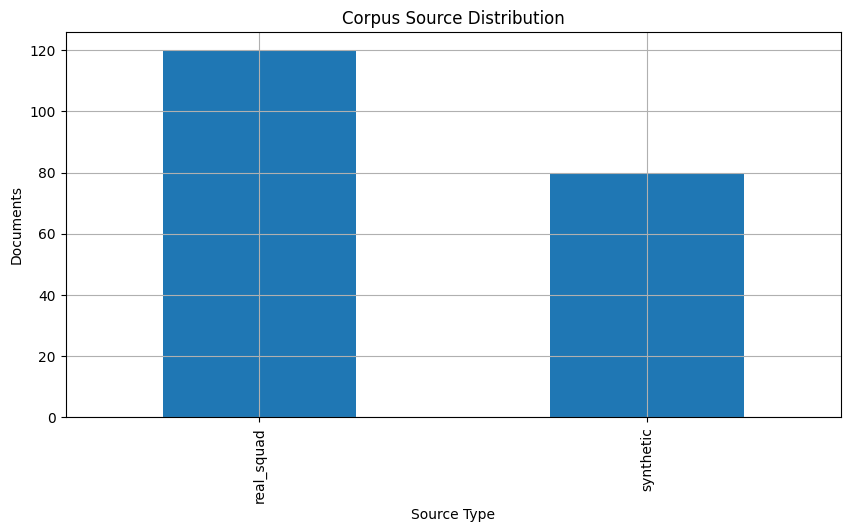

In [59]:
# Cell 059: Plot corpus source distribution
ax = source_counts.plot(kind="bar", x="source_type", y="count", legend=False, title="Corpus Source Distribution")
plt.xlabel("Source Type")
plt.ylabel("Documents")
plt.show()


In [60]:
# Cell 060: Query source distribution
query_source_counts = queries_df["source_type"].value_counts().reset_index()
query_source_counts.columns = ["source_type", "count"]
query_source_counts


,source_type,count
0,real_squad,120
1,synthetic,45


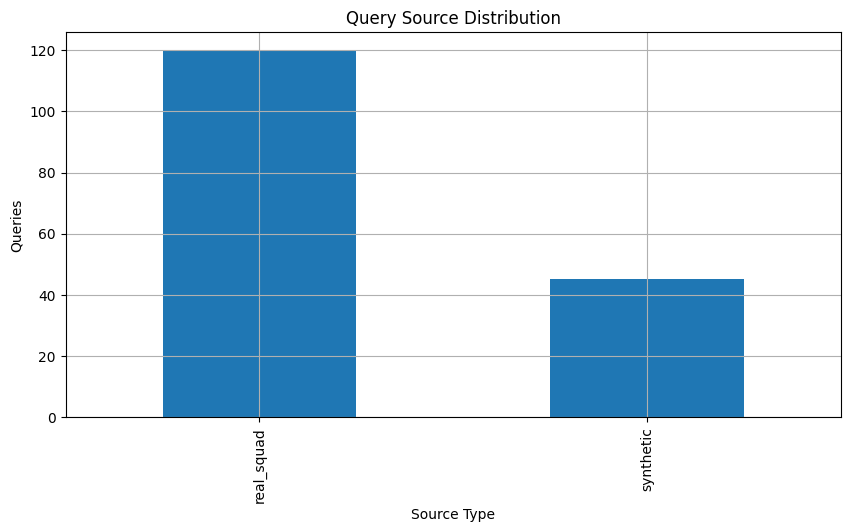

In [61]:
# Cell 061: Plot query source distribution
ax = query_source_counts.plot(kind="bar", x="source_type", y="count", legend=False, title="Query Source Distribution")
plt.xlabel("Source Type")
plt.ylabel("Queries")
plt.show()


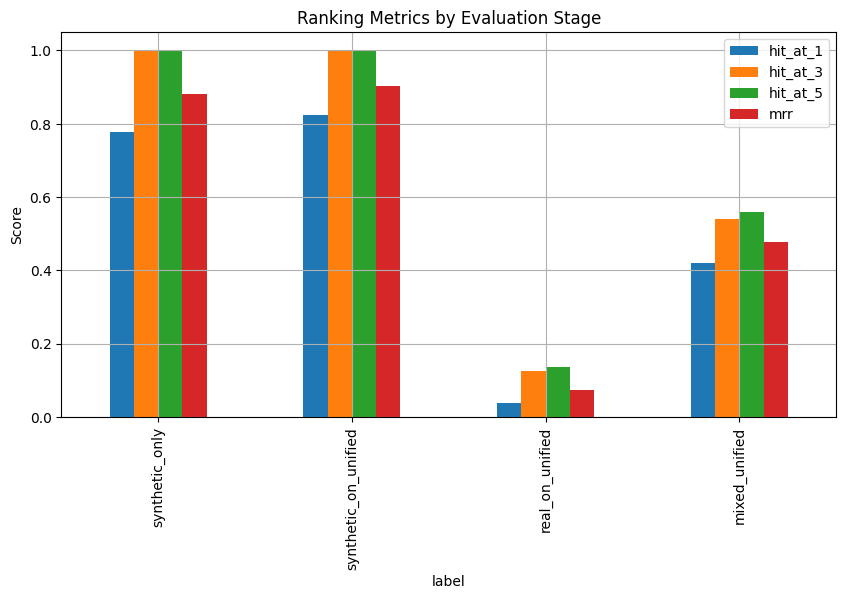

In [62]:
# Cell 062: Evaluation summary plot
summary_plot_df = summary_df.set_index("label")[["hit_at_1", "hit_at_3", "hit_at_5", "mrr"]]
summary_plot_df.plot(kind="bar", title="Ranking Metrics by Evaluation Stage")
plt.ylabel("Score")
plt.show()


In [63]:
# Cell 063: Latency analysis
latency_df = pd.concat([synthetic_eval_df, synthetic_on_unified_eval_df, real_eval_df, mixed_eval_df], ignore_index=True)
latency_df.groupby("eval_label")["latency_sec"].agg(["count", "mean", "median", "max"]).reset_index()


,eval_label,count,mean,median,max
0,mixed_unified,50,0.035802,0.033994,0.061836
1,real_on_unified,80,0.033232,0.033031,0.056010
2,synthetic_on_unified,45,0.029703,0.027039,0.061795
3,synthetic_only,45,0.027030,0.024309,0.075492


In [64]:
# Cell 064: Source-specific performance
if len(latency_df):
    display(latency_df.groupby(["eval_label", "source_type"])[["hit_at_1", "hit_at_3", "hit_at_5", "mrr"]].mean().reset_index())
else:
    print("No latency/evaluation data available.")


,eval_label,source_type,hit_at_1,hit_at_3,hit_at_5,mrr
0,mixed_unified,real_squad,0.040000,0.080,0.1200,0.061333
1,mixed_unified,synthetic,0.800000,1.000,1.0000,0.893333
2,real_on_unified,real_squad,0.037500,0.125,0.1375,0.073333
3,synthetic_on_unified,synthetic,0.822222,1.000,1.0000,0.903704
4,synthetic_only,synthetic,0.777778,1.000,1.0000,0.881481


In [65]:
# Cell 065: Failure cases helper
def get_failure_cases(eval_df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    if eval_df is None or len(eval_df) == 0:
        return pd.DataFrame()
    return eval_df[eval_df["hit_at_1"] == 0].head(n).copy()


In [66]:
# Cell 066: Synthetic failure cases
synthetic_failures = get_failure_cases(synthetic_on_unified_eval_df, 10)
show_df(synthetic_failures, 5)


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
7,synthetic_on_unified,SYN_Q_0007,synthetic,Which document explains supply chain with Stre...,Supply Chain playbook using Streamlit,SYN_DOC_0007,SYN_DOC_0037,0.0,1.0,1.0,0.500000,0.030779
13,synthetic_on_unified,SYN_Q_0013,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0067,SYN_DOC_0045,0.0,1.0,1.0,0.333333,0.054308
14,synthetic_on_unified,SYN_Q_0014,synthetic,Which document explains quality analytics with...,Quality Analytics playbook using FAISS,SYN_DOC_0057,SYN_DOC_0000,0.0,1.0,1.0,0.500000,0.061795
18,synthetic_on_unified,SYN_Q_0018,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0064,SYN_DOC_0077,0.0,1.0,1.0,0.500000,0.024007
23,synthetic_on_unified,SYN_Q_0023,synthetic,Which document explains supply chain with Azur...,Supply Chain playbook using Azure ML,SYN_DOC_0028,SYN_DOC_0078,0.0,1.0,1.0,0.500000,0.022728


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
7,synthetic_on_unified,SYN_Q_0007,synthetic,Which document explains supply chain with Stre...,Supply Chain playbook using Streamlit,SYN_DOC_0007,SYN_DOC_0037,0.0,1.0,1.0,0.500000,0.030779
13,synthetic_on_unified,SYN_Q_0013,synthetic,Which document explains customer support with ...,Customer Support playbook using Python,SYN_DOC_0067,SYN_DOC_0045,0.0,1.0,1.0,0.333333,0.054308
14,synthetic_on_unified,SYN_Q_0014,synthetic,Which document explains quality analytics with...,Quality Analytics playbook using FAISS,SYN_DOC_0057,SYN_DOC_0000,0.0,1.0,1.0,0.500000,0.061795
18,synthetic_on_unified,SYN_Q_0018,synthetic,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python,SYN_DOC_0064,SYN_DOC_0077,0.0,1.0,1.0,0.500000,0.024007
23,synthetic_on_unified,SYN_Q_0023,synthetic,Which document explains supply chain with Azur...,Supply Chain playbook using Azure ML,SYN_DOC_0028,SYN_DOC_0078,0.0,1.0,1.0,0.500000,0.022728


In [67]:
# Cell 067: Real failure cases
real_failures = get_failure_cases(real_eval_df, 10)
show_df(real_failures, 5)


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,real_on_unified,REAL_Q_00000,real_squad,Which NFL team represented the AFC at Super Bo...,Denver Broncos,REAL_SQUAD_00000_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,0.0,0.0,0.056010
1,real_on_unified,REAL_Q_00001,real_squad,Which NFL team represented the NFC at Super Bo...,Carolina Panthers,REAL_SQUAD_00001_Super_Bowl_50,REAL_SQUAD_00043_Super_Bowl_50,0.0,0.0,0.0,0.0,0.034761
2,real_on_unified,REAL_Q_00002,real_squad,Where did Super Bowl 50 take place?,"Santa Clara, California",REAL_SQUAD_00002_Super_Bowl_50,REAL_SQUAD_00014_Super_Bowl_50,0.0,0.0,0.0,0.0,0.044135
3,real_on_unified,REAL_Q_00003,real_squad,Which NFL team won Super Bowl 50?,Denver Broncos,REAL_SQUAD_00003_Super_Bowl_50,REAL_SQUAD_00038_Super_Bowl_50,0.0,0.0,0.0,0.0,0.033241
4,real_on_unified,REAL_Q_00004,real_squad,What color was used to emphasize the 50th anni...,gold,REAL_SQUAD_00004_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,1.0,0.2,0.042781


,eval_label,query_id,source_type,query,answer,relevant_doc_ids,top_doc_id,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,real_on_unified,REAL_Q_00000,real_squad,Which NFL team represented the AFC at Super Bo...,Denver Broncos,REAL_SQUAD_00000_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,0.0,0.0,0.056010
1,real_on_unified,REAL_Q_00001,real_squad,Which NFL team represented the NFC at Super Bo...,Carolina Panthers,REAL_SQUAD_00001_Super_Bowl_50,REAL_SQUAD_00043_Super_Bowl_50,0.0,0.0,0.0,0.0,0.034761
2,real_on_unified,REAL_Q_00002,real_squad,Where did Super Bowl 50 take place?,"Santa Clara, California",REAL_SQUAD_00002_Super_Bowl_50,REAL_SQUAD_00014_Super_Bowl_50,0.0,0.0,0.0,0.0,0.044135
3,real_on_unified,REAL_Q_00003,real_squad,Which NFL team won Super Bowl 50?,Denver Broncos,REAL_SQUAD_00003_Super_Bowl_50,REAL_SQUAD_00038_Super_Bowl_50,0.0,0.0,0.0,0.0,0.033241
4,real_on_unified,REAL_Q_00004,real_squad,What color was used to emphasize the 50th anni...,gold,REAL_SQUAD_00004_Super_Bowl_50,REAL_SQUAD_00019_Super_Bowl_50,0.0,0.0,1.0,0.2,0.042781


In [68]:
# Cell 068: Query length analysis
if len(latency_df):
    latency_df["query_len"] = latency_df["query"].map(lambda x: len(tokenize(x)))
    display(latency_df.groupby("source_type")["query_len"].agg(["count", "mean", "median", "max"]).reset_index())


,source_type,count,mean,median,max
0,real_squad,105,9.085714,9.0,18
1,synthetic,115,11.400000,11.0,12


In [69]:
# Cell 069: Document length analysis
corpus_df["text_len"] = corpus_df["text"].map(lambda x: len(tokenize(x)))
corpus_df.groupby("source_type")["text_len"].agg(["count", "mean", "median", "max"]).reset_index()


,source_type,count,mean,median,max
0,real_squad,120,84.858333,67.0,126
1,synthetic,80,37.425000,37.0,38


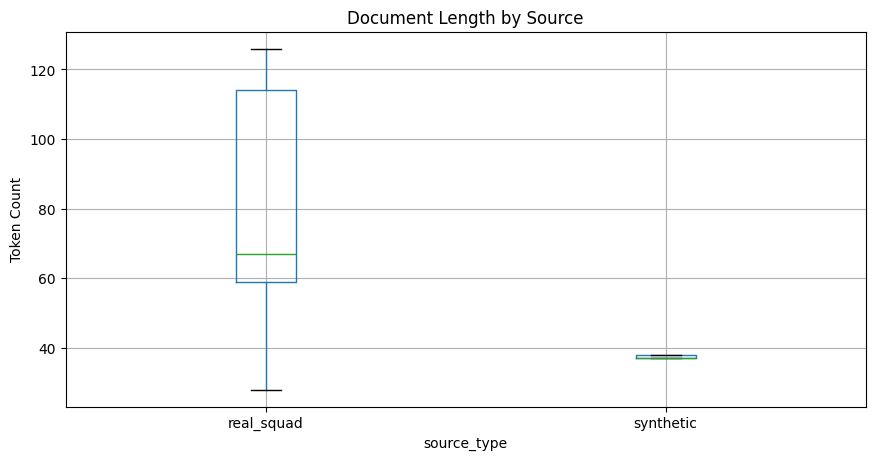

In [70]:
# Cell 070: Plot document length by source
corpus_df.boxplot(column="text_len", by="source_type")
plt.title("Document Length by Source")
plt.suptitle("")
plt.ylabel("Token Count")
plt.show()


In [71]:
# Cell 071: Backend manifest
backend_manifest = {
    "bi_encoder_backend": unified_ranker.bi_encoder.backend,
    "cross_encoder_backend": unified_ranker.cross_encoder.backend,
    "real_data_status": real_status,
    "real_data_available": REAL_DATA_AVAILABLE,
}
backend_manifest


{'bi_encoder_backend': 'sentence_transformer',
 'cross_encoder_backend': 'cross_encoder',
 'real_data_status': 'squad:validation[:120]',
 'real_data_available': True}

In [72]:
# Cell 072: Run directory helper
def make_run_dir(prefix: str = "document_ranking") -> Path:
    ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    run_dir = PROJECT_OUTPUT_DIR / f"{prefix}_{ts}"
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


In [73]:
# Cell 073: Export helper
def export_outputs(corpus_df: pd.DataFrame, queries_df: pd.DataFrame, eval_frames: Dict[str, pd.DataFrame], summary_df: pd.DataFrame, manifest: Dict[str, Any]) -> Dict[str, Path]:
    run_dir = make_run_dir()
    paths = {}
    paths["corpus_csv"] = run_dir / "corpus.csv"
    paths["queries_csv"] = run_dir / "queries.csv"
    paths["summary_csv"] = run_dir / "summary.csv"
    paths["excel"] = run_dir / "document_ranking_report.xlsx"
    paths["manifest"] = run_dir / "manifest.json"
    paths["zip"] = run_dir / "document_ranking_outputs.zip"

    corpus_df.to_csv(paths["corpus_csv"], index=False)
    queries_df.to_csv(paths["queries_csv"], index=False)
    summary_df.to_csv(paths["summary_csv"], index=False)

    with pd.ExcelWriter(paths["excel"], engine="openpyxl") as writer:
        corpus_df.to_excel(writer, sheet_name="corpus", index=False)
        queries_df.to_excel(writer, sheet_name="queries", index=False)
        summary_df.to_excel(writer, sheet_name="summary", index=False)
        for name, frame in eval_frames.items():
            clean_name = safe_slug(name, 28)
            frame.to_excel(writer, sheet_name=clean_name[:31], index=False)

    final_manifest = dict(manifest)
    final_manifest.update({"created_at": str(pd.Timestamp.now()), "run_dir": str(run_dir), "files": {k: str(v) for k, v in paths.items() if k != "zip"}})
    paths["manifest"].write_text(json.dumps(final_manifest, indent=2), encoding="utf-8")

    with zipfile.ZipFile(paths["zip"], "w", zipfile.ZIP_DEFLATED) as zf:
        for key, path in paths.items():
            if key != "zip" and path.exists():
                zf.write(path, arcname=path.name)
    return paths


In [74]:
# Cell 074: Export notebook outputs
eval_frames = {
    "synthetic_only": synthetic_eval_df,
    "synthetic_on_unified": synthetic_on_unified_eval_df,
    "real_on_unified": real_eval_df,
    "mixed_unified": mixed_eval_df,
}
export_paths = export_outputs(corpus_df, queries_df, eval_frames, summary_df, backend_manifest)
export_paths


{'corpus_csv': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/corpus.csv'),
 'queries_csv': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/queries.csv'),
 'summary_csv': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/summary.csv'),
 'excel': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/document_ranking_report.xlsx'),
 'manifest': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/manifest.json'),
 'zip': WindowsPath('outputs/document_ranking_project/document_ranking_20260428_123754/document_ranking_outputs.zip')}

In [75]:
# Cell 075: Confirm output files
for name, path in export_paths.items():
    print(name, "->", path, "exists:", path.exists())


corpus_csv -> outputs\document_ranking_project\document_ranking_20260428_123754\corpus.csv exists: True
queries_csv -> outputs\document_ranking_project\document_ranking_20260428_123754\queries.csv exists: True
summary_csv -> outputs\document_ranking_project\document_ranking_20260428_123754\summary.csv exists: True
excel -> outputs\document_ranking_project\document_ranking_20260428_123754\document_ranking_report.xlsx exists: True
manifest -> outputs\document_ranking_project\document_ranking_20260428_123754\manifest.json exists: True
zip -> outputs\document_ranking_project\document_ranking_20260428_123754\document_ranking_outputs.zip exists: True


In [76]:
# Cell 076: Additional analysis - top reranked source mix
if len(demo_reranked):
    display(demo_reranked["source_type"].value_counts().rename_axis("source_type").reset_index(name="count"))
else:
    print("No demo reranked rows.")


,source_type,count
0,synthetic,5


In [77]:
# Cell 077: Additional analysis - top title inspection
if len(demo_reranked):
    for i, row in enumerate(demo_reranked.head(3).itertuples(), start=1):
        print(f"Rank {i}: {row.title} | {row.source_type}")


Rank 1: Manufacturing Yield playbook using Python | synthetic
Rank 2: Manufacturing Yield playbook using Python | synthetic
Rank 3: Manufacturing Yield playbook using Python | synthetic


In [78]:
# Cell 078: Additional analysis - metric stability table
metric_cols = ["hit_at_1", "hit_at_3", "hit_at_5", "mrr"]
if len(latency_df):
    display(latency_df.groupby("eval_label")[metric_cols].agg(["mean", "std"]).round(4))


hit_at_1         hit_at_3         hit_at_5          \
                         mean     std     mean     std     mean     std   
eval_label                                                                
mixed_unified          0.4200  0.4986    0.540  0.5035   0.5600  0.5014   
real_on_unified        0.0375  0.1912    0.125  0.3328   0.1375  0.3465   
synthetic_on_unified   0.8222  0.3866    1.000  0.0000   1.0000  0.0000   
synthetic_only         0.7778  0.4204    1.000  0.0000   1.0000  0.0000   

                         mrr          
                        mean     std  
eval_label                            
mixed_unified         0.4773  0.4710  
real_on_unified       0.0733  0.2154  
synthetic_on_unified  0.9037  0.2117  
synthetic_only        0.8815  0.2265

In [79]:
# Cell 079: Additional analysis - latency percentile
if len(latency_df):
    display(latency_df.groupby("eval_label")["latency_sec"].quantile([0.5, 0.9, 0.95]).reset_index())


,eval_label,level_1,latency_sec
0,mixed_unified,0.50,0.033994
1,mixed_unified,0.90,0.055943
2,mixed_unified,0.95,0.056842
3,real_on_unified,0.50,0.033031
4,real_on_unified,0.90,0.042905
5,real_on_unified,0.95,0.044153
6,synthetic_on_unified,0.50,0.027039
7,synthetic_on_unified,0.90,0.034838
8,synthetic_on_unified,0.95,0.050800
9,synthetic_only,0.50,0.024309


In [80]:
# Cell 080: Additional analysis - source ratio
source_ratio = (corpus_df["source_type"].value_counts(normalize=True) * 100).round(2).reset_index()
source_ratio.columns = ["source_type", "percent"]
source_ratio


,source_type,percent
0,real_squad,60.0
1,synthetic,40.0


In [81]:
# Cell 081: Additional analysis - real data guardrail
assert len(synthetic_docs) > 0, "Synthetic documents should always exist."
if REAL_DATA_AVAILABLE:
    assert any(d.source_type.startswith("real") for d in unified_docs), "Real docs expected but not found."
print("Data guardrail checks passed.")


Data guardrail checks passed.


In [82]:
# Cell 082: Additional analysis - one-click verifier
def verify_synthetic_and_real_usage() -> Dict[str, Any]:
    counts = corpus_df["source_type"].value_counts().to_dict()
    return {
        "synthetic_present": any("synthetic" in k for k in counts),
        "real_present": any(k.startswith("real") for k in counts),
        "counts": counts,
        "real_status": real_status,
    }
verify_synthetic_and_real_usage()


{'synthetic_present': True,
 'real_present': True,
 'counts': {'real_squad': 120, 'synthetic': 80},
 'real_status': 'squad:validation[:120]'}

In [83]:
# Cell 083: Additional analysis - compare candidate vs reranked ranks
def compare_candidate_and_rerank(query: str) -> pd.DataFrame:
    candidates = unified_ranker.retrieve(query, top_k=CONFIG["bi_top_k"])
    reranked = unified_ranker.rerank(query, candidates, top_n=CONFIG["rerank_top_n"])
    return reranked[["doc_id", "title", "source_type", "bi_score", "cross_score", "rank_score"]] if len(reranked) else pd.DataFrame()
compare_candidate_and_rerank(demo_query)


,doc_id,title,source_type,bi_score,cross_score,rank_score
55,SYN_DOC_0055,Manufacturing Yield playbook using Python,synthetic,0.698837,9.294959,6.286316
70,SYN_DOC_0070,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
53,SYN_DOC_0053,Manufacturing Yield playbook using Python,synthetic,0.612770,6.487707,4.431479
64,SYN_DOC_0064,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345
77,SYN_DOC_0077,Manufacturing Yield playbook using Python,synthetic,0.612835,6.401311,4.375345


In [84]:
# Cell 084: Additional analysis - random query sample
sample_queries_df = queries_df.sample(min(5, len(queries_df)), random_state=SEED) if len(queries_df) else pd.DataFrame()
sample_queries_df[["query_id", "source_type", "query"]].reset_index(drop=True) if len(sample_queries_df) else sample_queries_df


,query_id,source_type,query
0,REAL_Q_00090,real_squad,Which network broadcasted the 50th Super Bowl ...
1,REAL_Q_00070,real_squad,How many tackles did Von Miller get during the...
2,REAL_Q_00086,real_squad,What was the average cost of a 30-second comme...
3,REAL_Q_00010,real_squad,What day was the Super Bowl played on?
4,REAL_Q_00050,real_squad,Who did Denver beat in the 2015 AFC Championsh...


In [85]:
# Cell 085: Additional analysis - batch demo over sample queries
batch_rows = []
for _, row in sample_queries_df.iterrows():
    hits = unified_ranker.search(row["query"])
    batch_rows.append({"query_id": row["query_id"], "source_type": row["source_type"], "top_doc_id": hits.iloc[0]["doc_id"] if len(hits) else ""})
batch_demo_df = pd.DataFrame(batch_rows)
batch_demo_df


,query_id,source_type,top_doc_id
0,REAL_Q_00090,real_squad,REAL_SQUAD_00019_Super_Bowl_50
1,REAL_Q_00070,real_squad,REAL_SQUAD_00078_Super_Bowl_50
2,REAL_Q_00086,real_squad,REAL_SQUAD_00093_Super_Bowl_50
3,REAL_Q_00010,real_squad,REAL_SQUAD_00019_Super_Bowl_50
4,REAL_Q_00050,real_squad,REAL_SQUAD_00078_Super_Bowl_50


In [86]:
# Cell 086: Additional analysis - save batch demo
batch_demo_path = PROJECT_OUTPUT_DIR / "latest_batch_demo.csv"
batch_demo_df.to_csv(batch_demo_path, index=False)
batch_demo_path


WindowsPath('outputs/document_ranking_project/latest_batch_demo.csv')

In [87]:
# Cell 087: Additional analysis - simple explainability helper
def explain_hit(query: str, doc_text: str) -> pd.DataFrame:
    q_tokens = set(tokenize(query))
    rows = []
    for tok in sorted(q_tokens):
        rows.append({"query_token": tok, "in_doc": tok in set(tokenize(doc_text))})
    return pd.DataFrame(rows)
if len(demo_reranked):
    explain_hit(demo_query, demo_reranked.iloc[0]["text"]).head(20)
else:
    pd.DataFrame()


In [88]:
# Cell 088: Additional analysis - backend notes
backend_notes = pd.DataFrame([
    {"component": "bi_encoder", "backend": unified_ranker.bi_encoder.backend, "purpose": "fast candidate retrieval"},
    {"component": "cross_encoder", "backend": unified_ranker.cross_encoder.backend, "purpose": "precise pairwise reranking"},
])
backend_notes


,component,backend,purpose
0,bi_encoder,sentence_transformer,fast candidate retrieval
1,cross_encoder,cross_encoder,precise pairwise reranking


In [89]:
# Cell 089: Additional analysis - write backend notes
backend_notes_path = PROJECT_OUTPUT_DIR / "backend_notes.csv"
backend_notes.to_csv(backend_notes_path, index=False)
backend_notes_path


WindowsPath('outputs/document_ranking_project/backend_notes.csv')

In [90]:
# Cell 090: Additional analysis - export latest summary copy
latest_summary_path = PROJECT_OUTPUT_DIR / "latest_summary.csv"
summary_df.to_csv(latest_summary_path, index=False)
latest_summary_path


WindowsPath('outputs/document_ranking_project/latest_summary.csv')

In [91]:
# Cell 091: Additional analysis - check output zip
zip_path = export_paths.get("zip")
print(zip_path, zip_path.exists() if zip_path else False)


outputs\document_ranking_project\document_ranking_20260428_123754\document_ranking_outputs.zip True


In [92]:
# Cell 092: Additional analysis - report file sizes
file_size_rows = []
for name, path in export_paths.items():
    if path.exists():
        file_size_rows.append({"file": path.name, "size_kb": round(path.stat().st_size / 1024, 2)})
pd.DataFrame(file_size_rows)


,file,size_kb
0,corpus.csv,102.27
1,queries.csv,27.91
2,summary.csv,0.38
3,document_ranking_report.xlsx,41.84
4,manifest.json,0.84
5,document_ranking_outputs.zip,48.07


In [93]:
# Cell 093: Additional analysis - model limitations
limitations = [
    "If sentence-transformers is unavailable, the notebook uses TF-IDF and lexical reranking fallbacks.",
    "Real data requires the datasets package and internet access.",
    "SQuAD is used as a real public QA-to-document ranking benchmark.",
]
for item in limitations:
    print("-", item)


- If sentence-transformers is unavailable, the notebook uses TF-IDF and lexical reranking fallbacks.
- Real data requires the datasets package and internet access.
- SQuAD is used as a real public QA-to-document ranking benchmark.


In [94]:
# Cell 094: Additional analysis - recommended portfolio talking points
talking_points = [
    "Synthetic validation before real-data evaluation.",
    "Bi-encoder candidate retrieval followed by cross-encoder reranking.",
    "Unified corpus containing synthetic and real public examples.",
    "Metrics include Hit@K, MRR, and latency.",
    "Output layer exports CSV, Excel, manifest, and ZIP bundle.",
]
talking_points


['Synthetic validation before real-data evaluation.',
 'Bi-encoder candidate retrieval followed by cross-encoder reranking.',
 'Unified corpus containing synthetic and real public examples.',
 'Metrics include Hit@K, MRR, and latency.',
 'Output layer exports CSV, Excel, manifest, and ZIP bundle.']

In [95]:
# Cell 095: Additional analysis - sanity check for required columns
required_doc_cols = {"doc_id", "title", "text", "source_type"}
required_query_cols = {"query_id", "query", "relevant_doc_ids", "source_type"}
print(required_doc_cols.issubset(corpus_df.columns))
print(required_query_cols.issubset(queries_df.columns))


True
True


In [96]:
# Cell 096: Additional analysis - deduplicate corpus
dedup_corpus_df = corpus_df.drop_duplicates("doc_id").copy()
print("before:", len(corpus_df), "after:", len(dedup_corpus_df))


before: 200 after: 200


In [97]:
# Cell 097: Additional analysis - deduplicate queries
dedup_queries_df = queries_df.drop_duplicates("query_id").copy()
print("before:", len(queries_df), "after:", len(dedup_queries_df))


before: 165 after: 165


In [98]:
# Cell 098: Additional analysis - title uniqueness
title_counts = corpus_df["title"].value_counts().head(10).reset_index()
title_counts.columns = ["title", "count"]
title_counts


,title,count
0,Super_Bowl_50,120
1,Supply Chain playbook using Streamlit,8
2,Manufacturing Yield playbook using SQL Server,6
3,Quality Analytics playbook using Streamlit,5
4,Supply Chain playbook using SQL Server,5
5,Manufacturing Yield playbook using Python,5
6,Quality Analytics playbook using FAISS,4
7,Quality Analytics playbook using Python,4
8,Manufacturing Yield playbook using FAISS,4
9,Predictive Maintenance playbook using FAISS,3


In [99]:
# Cell 099: Additional analysis - short documents
short_docs = corpus_df[corpus_df["text_len"] < 20][["doc_id", "title", "source_type", "text_len"]]
short_docs.head(10)


,doc_id,title,source_type,text_len


In [100]:
# Cell 100: Additional analysis - long documents
long_docs = corpus_df.sort_values("text_len", ascending=False)[["doc_id", "title", "source_type", "text_len"]].head(10)
long_docs


,doc_id,title,source_type,text_len
100,REAL_SQUAD_00020_Super_Bowl_50,Super_Bowl_50,real_squad,126
95,REAL_SQUAD_00015_Super_Bowl_50,Super_Bowl_50,real_squad,126
108,REAL_SQUAD_00028_Super_Bowl_50,Super_Bowl_50,real_squad,126
107,REAL_SQUAD_00027_Super_Bowl_50,Super_Bowl_50,real_squad,126
106,REAL_SQUAD_00026_Super_Bowl_50,Super_Bowl_50,real_squad,126
105,REAL_SQUAD_00025_Super_Bowl_50,Super_Bowl_50,real_squad,126
104,REAL_SQUAD_00024_Super_Bowl_50,Super_Bowl_50,real_squad,126
103,REAL_SQUAD_00023_Super_Bowl_50,Super_Bowl_50,real_squad,126
102,REAL_SQUAD_00022_Super_Bowl_50,Super_Bowl_50,real_squad,126
101,REAL_SQUAD_00021_Super_Bowl_50,Super_Bowl_50,real_squad,126


In [101]:
# Cell 101: Additional analysis - real query answer preview
if len(real_queries_df):
    display(real_queries_df[["query_id", "query", "answer"]].head(5))
else:
    print("No real queries loaded in this run.")


,query_id,query,answer
0,REAL_Q_00000,Which NFL team represented the AFC at Super Bo...,Denver Broncos
1,REAL_Q_00001,Which NFL team represented the NFC at Super Bo...,Carolina Panthers
2,REAL_Q_00002,Where did Super Bowl 50 take place?,"Santa Clara, California"
3,REAL_Q_00003,Which NFL team won Super Bowl 50?,Denver Broncos
4,REAL_Q_00004,What color was used to emphasize the 50th anni...,gold


In [102]:
# Cell 102: Additional analysis - synthetic answer preview
synthetic_queries_df[["query_id", "query", "answer"]].head(5)


,query_id,query,answer
0,SYN_Q_0000,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using Python
1,SYN_Q_0001,Which document explains customer support with ...,Customer Support playbook using Python
2,SYN_Q_0002,Which document explains supply chain with SQL ...,Supply Chain playbook using SQL Server
3,SYN_Q_0003,Which document explains manufacturing yield wi...,Manufacturing Yield playbook using FAISS
4,SYN_Q_0004,Which document explains supply chain with Pyth...,Supply Chain playbook using Python


In [103]:
# Cell 103: Additional analysis - latest export manifest
manifest_path = export_paths.get("manifest")
if manifest_path and manifest_path.exists():
    print(manifest_path.read_text(encoding="utf-8")[:1000])


{
  "bi_encoder_backend": "sentence_transformer",
  "cross_encoder_backend": "cross_encoder",
  "real_data_status": "squad:validation[:120]",
  "real_data_available": true,
  "created_at": "2026-04-28 12:37:54.491501",
  "run_dir": "outputs\\document_ranking_project\\document_ranking_20260428_123754",
  "files": {
    "corpus_csv": "outputs\\document_ranking_project\\document_ranking_20260428_123754\\corpus.csv",
    "queries_csv": "outputs\\document_ranking_project\\document_ranking_20260428_123754\\queries.csv",
    "summary_csv": "outputs\\document_ranking_project\\document_ranking_20260428_123754\\summary.csv",
    "excel": "outputs\\document_ranking_project\\document_ranking_20260428_123754\\document_ranking_report.xlsx",
    "manifest": "outputs\\document_ranking_project\\document_ranking_20260428_123754\\manifest.json"
  }
}


In [104]:
# Cell 104: Additional analysis - environment summary
env_summary = {
    "has_datasets": HAS_DATASETS,
    "has_sentence_transformers": HAS_SENTENCE_TRANSFORMERS,
    "python_executable": sys.executable if "sys" in globals() else "not_imported",
}
env_summary


{'has_datasets': True,
 'has_sentence_transformers': True,
 'python_executable': 'not_imported'}

In [105]:
# Cell 105: Additional analysis - import sys for manifest enrichment
import sys
env_summary["python_version"] = sys.version
env_summary


{'has_datasets': True,
 'has_sentence_transformers': True,
 'python_executable': 'not_imported',
 'python_version': '3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]'}

In [106]:
# Cell 106: Additional analysis - write environment summary
env_summary_path = PROJECT_OUTPUT_DIR / "environment_summary.json"
env_summary_path.write_text(json.dumps(env_summary, indent=2), encoding="utf-8")
env_summary_path


WindowsPath('outputs/document_ranking_project/environment_summary.json')

In [107]:
# Cell 107: Additional analysis - expected project flow
project_flow = pd.DataFrame([
    {"stage": 1, "name": "synthetic_validation", "description": "Build synthetic documents and queries."},
    {"stage": 2, "name": "real_public_data", "description": "Load public SQuAD QA data and convert it to ranking pairs."},
    {"stage": 3, "name": "unified_ranking", "description": "Use the same bi-encoder and cross-encoder pipeline."},
    {"stage": 4, "name": "outputs", "description": "Export CSV, Excel, manifest, ZIP bundle."},
    {"stage": 5, "name": "streamlit", "description": "Interactive app generated at the final notebook section."},
])
project_flow


,stage,name,description
0,1,synthetic_validation,Build synthetic documents and queries.
1,2,real_public_data,Load public SQuAD QA data and convert it to ra...
2,3,unified_ranking,Use the same bi-encoder and cross-encoder pipe...
3,4,outputs,"Export CSV, Excel, manifest, ZIP bundle."
4,5,streamlit,Interactive app generated at the final noteboo...


In [108]:
# Cell 108: Additional analysis - save project flow
project_flow_path = PROJECT_OUTPUT_DIR / "project_flow.csv"
project_flow.to_csv(project_flow_path, index=False)
project_flow_path


WindowsPath('outputs/document_ranking_project/project_flow.csv')

In [109]:
# Cell 109: Additional analysis - confirm Streamlit final-section policy
print("The Streamlit code export starts in the final notebook section after all analysis and exports.")


The Streamlit code export starts in the final notebook section after all analysis and exports.


In [110]:
# Cell 110: Additional analysis - final data usage statement
usage_statement = verify_synthetic_and_real_usage()
usage_statement


{'synthetic_present': True,
 'real_present': True,
 'counts': {'real_squad': 120, 'synthetic': 80},
 'real_status': 'squad:validation[:120]'}

In [111]:
# Cell 111: Additional analysis - optional real-data warning
if not usage_statement["real_present"]:
    print("WARNING: Real data was not loaded in this runtime. Install datasets and ensure internet access.")
else:
    print("Synthetic and real public data are both present.")


Synthetic and real public data are both present.


In [112]:
# Cell 112: Additional analysis - save usage statement
usage_path = PROJECT_OUTPUT_DIR / "data_usage_statement.json"
usage_path.write_text(json.dumps(usage_statement, indent=2), encoding="utf-8")
usage_path


WindowsPath('outputs/document_ranking_project/data_usage_statement.json')

In [113]:
# Cell 113: Additional analysis - final metric selection
final_metric_table = summary_df[["label", "queries", "hit_at_1", "hit_at_3", "hit_at_5", "mrr", "latency_sec"]].copy()
final_metric_table


,label,queries,hit_at_1,hit_at_3,hit_at_5,mrr,latency_sec
0,synthetic_only,45,0.777778,1.000,1.0000,0.881481,0.027030
1,synthetic_on_unified,45,0.822222,1.000,1.0000,0.903704,0.029703
2,real_on_unified,80,0.037500,0.125,0.1375,0.073333,0.033232
3,mixed_unified,50,0.420000,0.540,0.5600,0.477333,0.035802


In [114]:
# Cell 114: Additional analysis - save final metric table
final_metric_path = PROJECT_OUTPUT_DIR / "final_metric_table.csv"
final_metric_table.to_csv(final_metric_path, index=False)
final_metric_path


WindowsPath('outputs/document_ranking_project/final_metric_table.csv')

In [115]:
# Cell 115: Additional analysis - notebook completion checkpoint
print("Document ranking pipeline completed through synthetic, real/unified evaluation, outputs, and Streamlit export preparation.")


Document ranking pipeline completed through synthetic, real/unified evaluation, outputs, and Streamlit export preparation.


In [116]:
# Cell 116: Streamlit section starts here
print("Final section: write standalone Streamlit app file.")


Final section: write standalone Streamlit app file.


In [117]:
# Cell 117: Define Streamlit app code string
STREAMLIT_APP_CODE = '#!/usr/bin/env python\n# -*- coding: utf-8 -*-\n\n"""\nDocRank360: Bi-Encoder + Cross-Encoder Document Ranking\nSynthetic-first + real public data pipeline with Streamlit UI.\n\nRun:\n    streamlit run document_ranking_bi_cross_streamlit_app.py\n"""\n\nimport os\nimport re\nimport json\nimport time\nimport random\nimport zipfile\nfrom pathlib import Path\nfrom dataclasses import dataclass, asdict\nfrom typing import Any, Dict, List, Optional, Tuple\n\nimport numpy as np\nimport pandas as pd\nimport streamlit as st\n\ntry:\n    from datasets import load_dataset\n    HAS_DATASETS = True\nexcept Exception:\n    load_dataset = None\n    HAS_DATASETS = False\n\ntry:\n    from sentence_transformers import SentenceTransformer, CrossEncoder\n    HAS_SENTENCE_TRANSFORMERS = True\nexcept Exception:\n    SentenceTransformer = None\n    CrossEncoder = None\n    HAS_SENTENCE_TRANSFORMERS = False\n\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.metrics.pairwise import cosine_similarity\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\nPROJECT_NAME = "DocRank360"\nOUTPUT_ROOT = Path("outputs")\nSYNTHETIC_DOCS = 80\nSYNTHETIC_QUERIES = 45\nREAL_EXAMPLES = 120\nTOP_K = 10\nRERANK_TOP_N = 5\nBI_ENCODER_MODEL = "sentence-transformers/all-MiniLM-L6-v2"\nCROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"\n\n@dataclass\nclass DocumentRecord:\n    doc_id: str\n    title: str\n    text: str\n    source_type: str\n    metadata: Optional[Dict[str, Any]] = None\n\n@dataclass\nclass QueryRecord:\n    query_id: str\n    query: str\n    relevant_doc_ids: List[str]\n    answer: str\n    source_type: str\n    metadata: Optional[Dict[str, Any]] = None\n\ndef normalize_text(text: Any) -> str:\n    if text is None or (isinstance(text, float) and pd.isna(text)):\n        return ""\n    text = str(text).replace("\\xa0", " ")\n    text = re.sub(r"\\s+", " ", text)\n    text = re.sub(r"[^\\x00-\\x7F]+", " ", text)\n    return text.strip()\n\ndef tokenize(text: Any) -> List[str]:\n    return re.findall(r"[A-Za-z0-9_\\-]+", normalize_text(text).lower())\n\ndef safe_slug(text: Any, max_len: int = 60) -> str:\n    value = re.sub(r"[^A-Za-z0-9]+", "_", normalize_text(text))\n    value = value.strip("_")[:max_len]\n    return value or "item"\n\ndef make_run_dir(prefix: str = "document_ranking") -> Path:\n    ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")\n    run_dir = OUTPUT_ROOT / f"{prefix}_{ts}"\n    run_dir.mkdir(parents=True, exist_ok=True)\n    return run_dir\n\ndef build_synthetic_corpus(n_docs: int = SYNTHETIC_DOCS, n_queries: int = SYNTHETIC_QUERIES) -> Tuple[List[DocumentRecord], List[QueryRecord]]:\n    domains = ["quality analytics", "supply chain", "predictive maintenance", "customer support", "manufacturing yield"]\n    tools = ["FAISS", "Power BI", "SQL Server", "Azure ML", "Python", "Streamlit"]\n    risks = ["latency drift", "data leakage", "sensor noise", "missing values", "class imbalance"]\n    docs: List[DocumentRecord] = []\n    queries: List[QueryRecord] = []\n\n    for i in range(n_docs):\n        domain = random.choice(domains)\n        tool = random.choice(tools)\n        risk = random.choice(risks)\n        title = f"{domain.title()} playbook using {tool}"\n        text = (\n            f"This document explains how a team used {tool} for {domain}. "\n            f"It describes data ingestion, preprocessing, ranking, monitoring, and evaluation. "\n            f"The primary risk discussed is {risk}. "\n            f"The recommended mitigation is validation checks, logging, and metric review."\n        )\n        docs.append(DocumentRecord(\n            doc_id=f"SYN_DOC_{i:04d}",\n            title=title,\n            text=text,\n            source_type="synthetic",\n            metadata={"domain": domain, "tool": tool, "risk": risk},\n        ))\n\n    eligible = random.sample(docs, min(n_queries, len(docs)))\n    for j, doc in enumerate(eligible):\n        md = doc.metadata or {}\n        query = f"Which document explains {md.get(\'domain\')} with {md.get(\'tool\')} and discusses {md.get(\'risk\')}?"\n        queries.append(QueryRecord(\n            query_id=f"SYN_Q_{j:04d}",\n            query=query,\n            relevant_doc_ids=[doc.doc_id],\n            answer=doc.title,\n            source_type="synthetic",\n            metadata={"target_title": doc.title},\n        ))\n    return docs, queries\n\ndef _parse_squad_row(row: Dict[str, Any], idx: int) -> Tuple[Optional[DocumentRecord], Optional[QueryRecord]]:\n    title = normalize_text(row.get("title", f"SQuAD article {idx}"))\n    context = normalize_text(row.get("context", ""))\n    question = normalize_text(row.get("question", ""))\n    answers = row.get("answers", {})\n    answer_text = ""\n    if isinstance(answers, dict):\n        vals = answers.get("text", [])\n        answer_text = normalize_text(vals[0]) if vals else ""\n    if not context or not question:\n        return None, None\n    doc_id = f"REAL_SQUAD_{idx:05d}_{safe_slug(title, 35)}"\n    doc = DocumentRecord(\n        doc_id=doc_id,\n        title=title,\n        text=context,\n        source_type="real_squad",\n        metadata={"dataset": "squad"},\n    )\n    query = QueryRecord(\n        query_id=f"REAL_Q_{idx:05d}",\n        query=question,\n        relevant_doc_ids=[doc_id],\n        answer=answer_text,\n        source_type="real_squad",\n        metadata={"title": title},\n    )\n    return doc, query\n\ndef load_real_public_dataset(max_examples: int = REAL_EXAMPLES) -> Tuple[List[DocumentRecord], List[QueryRecord], str]:\n    if not HAS_DATASETS:\n        return [], [], "datasets_not_installed"\n    attempts = [\n        ("squad", None, f"validation[:{max_examples}]"),\n        ("squad", None, f"train[:{max_examples}]"),\n    ]\n    last_error = None\n    for name, subset, split in attempts:\n        try:\n            ds = load_dataset(name, split=split) if subset is None else load_dataset(name, subset, split=split)\n            docs, queries = [], []\n            seen = set()\n            for idx, row in enumerate(ds):\n                doc, query = _parse_squad_row(row, idx)\n                if doc is None or query is None:\n                    continue\n                if doc.doc_id not in seen:\n                    docs.append(doc)\n                    seen.add(doc.doc_id)\n                queries.append(query)\n            if docs and queries:\n                return docs, queries, f"{name}:{split}"\n        except Exception as exc:\n            last_error = exc\n    return [], [], f"failed:{type(last_error).__name__ if last_error else \'unknown\'}"\n\nclass BiEncoderBackend:\n    def __init__(self, model_name: str = BI_ENCODER_MODEL):\n        self.backend = "tfidf"\n        self.model = None\n        self.vectorizer = None\n        if HAS_SENTENCE_TRANSFORMERS:\n            try:\n                self.model = SentenceTransformer(model_name)\n                self.backend = "sentence_transformer"\n            except Exception:\n                self.model = None\n        if self.backend == "tfidf":\n            self.vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")\n\n    def fit(self, texts: List[str]) -> None:\n        if self.backend == "tfidf":\n            self.vectorizer.fit(texts)\n\n    def encode(self, texts: List[str]) -> np.ndarray:\n        texts = [normalize_text(x) for x in texts]\n        if self.backend == "sentence_transformer":\n            arr = self.model.encode(texts, batch_size=32, show_progress_bar=False, normalize_embeddings=True)\n            return np.asarray(arr, dtype="float32")\n        arr = self.vectorizer.transform(texts).astype(np.float32).toarray()\n        norms = np.linalg.norm(arr, axis=1, keepdims=True)\n        norms[norms == 0] = 1.0\n        return arr / norms\n\nclass CrossEncoderReranker:\n    def __init__(self, model_name: str = CROSS_ENCODER_MODEL):\n        self.backend = "lexical"\n        self.model = None\n        if HAS_SENTENCE_TRANSFORMERS:\n            try:\n                self.model = CrossEncoder(model_name)\n                self.backend = "cross_encoder"\n            except Exception:\n                self.model = None\n\n    def score(self, query: str, docs: List[str]) -> np.ndarray:\n        query = normalize_text(query)\n        docs = [normalize_text(x) for x in docs]\n        if not docs:\n            return np.array([], dtype=float)\n        if self.backend == "cross_encoder":\n            pairs = [[query, doc] for doc in docs]\n            scores = self.model.predict(pairs)\n            return np.asarray(scores, dtype=float)\n        q_tokens = set(tokenize(query))\n        scores = []\n        for doc in docs:\n            d_tokens = set(tokenize(doc))\n            overlap = len(q_tokens & d_tokens) / max(len(q_tokens), 1)\n            phrase_bonus = 0.15 if query.lower() in doc.lower() else 0.0\n            scores.append(overlap + phrase_bonus)\n        return np.asarray(scores, dtype=float)\n\nclass UnifiedRanker:\n    def __init__(self, docs: List[DocumentRecord]):\n        self.docs = docs\n        self.doc_df = pd.DataFrame([asdict(d) for d in docs])\n        self.bi_encoder = BiEncoderBackend()\n        self.cross_encoder = CrossEncoderReranker()\n        self.ready = False\n        if len(self.doc_df):\n            self._fit()\n\n    def _fit(self) -> None:\n        self.doc_df["search_text"] = (\n            self.doc_df["title"].fillna("").astype(str) + " " +\n            self.doc_df["text"].fillna("").astype(str)\n        ).map(normalize_text)\n        texts = self.doc_df["search_text"].tolist()\n        self.bi_encoder.fit(texts)\n        self.doc_embeddings = self.bi_encoder.encode(texts).astype("float32")\n        self.ready = True\n\n    def retrieve(self, query: str, top_k: int = TOP_K) -> pd.DataFrame:\n        if not self.ready or len(self.doc_df) == 0:\n            return pd.DataFrame()\n        q_emb = self.bi_encoder.encode([query]).astype("float32")[0]\n        scores = (self.doc_embeddings @ q_emb).ravel()\n        k = min(top_k, len(scores))\n        idxs = np.argsort(scores)[::-1][:k]\n        out = self.doc_df.iloc[idxs].copy()\n        out["bi_score"] = scores[idxs]\n        return out\n\n    def rerank(self, query: str, candidates: pd.DataFrame, top_n: int = RERANK_TOP_N) -> pd.DataFrame:\n        if candidates is None or len(candidates) == 0:\n            return pd.DataFrame()\n        out = candidates.copy()\n        docs = out["search_text"].fillna("").astype(str).tolist()\n        out["cross_score"] = self.cross_encoder.score(query, docs)\n        out["rank_score"] = 0.35 * out["bi_score"].astype(float) + 0.65 * out["cross_score"].astype(float)\n        return out.sort_values("rank_score", ascending=False).head(top_n).copy()\n\n    def search(self, query: str, top_k: int = TOP_K, rerank_top_n: int = RERANK_TOP_N) -> pd.DataFrame:\n        candidates = self.retrieve(query, top_k=top_k)\n        return self.rerank(query, candidates, top_n=rerank_top_n)\n\ndef hit_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:\n    return float(bool(set(retrieved_ids[:k]) & set(relevant_ids)))\n\ndef reciprocal_rank(retrieved_ids: List[str], relevant_ids: List[str]) -> float:\n    relevant = set(relevant_ids)\n    for idx, doc_id in enumerate(retrieved_ids, start=1):\n        if doc_id in relevant:\n            return 1.0 / idx\n    return 0.0\n\ndef evaluate_ranker(ranker: UnifiedRanker, queries: List[QueryRecord], limit: Optional[int] = None) -> pd.DataFrame:\n    rows = []\n    use_queries = queries[:limit] if limit else queries\n    for q in use_queries:\n        t0 = time.perf_counter()\n        hits = ranker.search(q.query)\n        latency = time.perf_counter() - t0\n        retrieved = hits["doc_id"].tolist() if len(hits) else []\n        rows.append({\n            "query_id": q.query_id,\n            "source_type": q.source_type,\n            "query": q.query,\n            "answer": q.answer,\n            "relevant_doc_ids": "|".join(q.relevant_doc_ids),\n            "top_doc_id": retrieved[0] if retrieved else "",\n            "hit_at_1": hit_at_k(retrieved, q.relevant_doc_ids, 1),\n            "hit_at_3": hit_at_k(retrieved, q.relevant_doc_ids, 3),\n            "hit_at_5": hit_at_k(retrieved, q.relevant_doc_ids, 5),\n            "mrr": reciprocal_rank(retrieved, q.relevant_doc_ids),\n            "latency_sec": latency,\n        })\n    return pd.DataFrame(rows)\n\ndef summarize_eval(df: pd.DataFrame, label: str) -> pd.DataFrame:\n    if df is None or len(df) == 0:\n        return pd.DataFrame([{"label": label, "queries": 0, "hit_at_1": 0, "hit_at_3": 0, "hit_at_5": 0, "mrr": 0, "latency_sec": 0}])\n    return pd.DataFrame([{\n        "label": label,\n        "queries": len(df),\n        "hit_at_1": df["hit_at_1"].mean(),\n        "hit_at_3": df["hit_at_3"].mean(),\n        "hit_at_5": df["hit_at_5"].mean(),\n        "mrr": df["mrr"].mean(),\n        "latency_sec": df["latency_sec"].mean(),\n    }])\n\ndef build_system(mode: str = "synthetic_plus_real") -> Tuple[UnifiedRanker, pd.DataFrame, List[QueryRecord], str]:\n    syn_docs, syn_queries = build_synthetic_corpus()\n    docs = list(syn_docs)\n    queries = list(syn_queries)\n    real_status = "not_requested"\n    if mode == "synthetic_plus_real":\n        real_docs, real_queries, real_status = load_real_public_dataset()\n        if real_docs and real_queries:\n            docs.extend(real_docs)\n            queries.extend(real_queries)\n        else:\n            real_status = f"{real_status}; using synthetic only"\n    ranker = UnifiedRanker(docs)\n    corpus_df = pd.DataFrame([asdict(d) for d in docs])\n    return ranker, corpus_df, queries, real_status\n\ndef export_results(corpus_df: pd.DataFrame, eval_df: pd.DataFrame, summary_df: pd.DataFrame) -> Tuple[Path, Path]:\n    run_dir = make_run_dir("document_ranking")\n    corpus_path = run_dir / "corpus.csv"\n    eval_path = run_dir / "ranking_eval.csv"\n    summary_path = run_dir / "summary.csv"\n    excel_path = run_dir / "document_ranking_report.xlsx"\n    zip_path = run_dir / "document_ranking_outputs.zip"\n\n    corpus_df.to_csv(corpus_path, index=False)\n    eval_df.to_csv(eval_path, index=False)\n    summary_df.to_csv(summary_path, index=False)\n    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:\n        corpus_df.to_excel(writer, sheet_name="corpus", index=False)\n        eval_df.to_excel(writer, sheet_name="evaluation", index=False)\n        summary_df.to_excel(writer, sheet_name="summary", index=False)\n    manifest = {"project": PROJECT_NAME, "created_at": str(pd.Timestamp.now()), "files": [p.name for p in [corpus_path, eval_path, summary_path, excel_path]]}\n    (run_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")\n    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:\n        for p in [corpus_path, eval_path, summary_path, excel_path, run_dir / "manifest.json"]:\n            zf.write(p, arcname=p.name)\n    return excel_path, zip_path\n\nst.set_page_config(page_title="DocRank360", layout="wide")\nst.title("DocRank360: Bi-Encoder + Cross-Encoder Ranking")\nst.caption("Synthetic data is built first. Real public SQuAD ranking data is then added to the same bi-encoder retrieval and cross-encoder reranking pipeline.")\n\nwith st.sidebar:\n    mode = st.selectbox("Corpus mode", ["synthetic_only", "synthetic_plus_real"], index=1)\n    top_k = st.slider("Bi-encoder candidate count", 3, 30, TOP_K)\n    rerank_top_n = st.slider("Cross-encoder final results", 1, 10, RERANK_TOP_N)\n    build = st.button("Build / refresh ranking system", type="primary")\n\nif "ranker" not in st.session_state or build or st.session_state.get("mode") != mode:\n    with st.spinner("Building ranking system..."):\n        ranker, corpus_df, queries, real_status = build_system(mode)\n    st.session_state["ranker"] = ranker\n    st.session_state["corpus_df"] = corpus_df\n    st.session_state["queries"] = queries\n    st.session_state["real_status"] = real_status\n    st.session_state["mode"] = mode\n\nranker = st.session_state["ranker"]\ncorpus_df = st.session_state["corpus_df"]\nqueries = st.session_state["queries"]\nreal_status = st.session_state["real_status"]\n\nleft, right = st.columns([1.7, 1.0])\n\nwith left:\n    query = st.text_area("Enter a search query", value="Which document discusses ranking, monitoring, and evaluation?", height=110)\n    if st.button("Run bi-encoder retrieval + cross-encoder reranking"):\n        hits = ranker.retrieve(query, top_k=top_k)\n        reranked = ranker.rerank(query, hits, top_n=rerank_top_n)\n        st.subheader("Reranked results")\n        if len(reranked):\n            show_cols = ["doc_id", "title", "source_type", "bi_score", "cross_score", "rank_score"]\n            st.dataframe(reranked[show_cols], use_container_width=True)\n            for i, row in enumerate(reranked.itertuples(), start=1):\n                with st.expander(f"Rank {i}: {row.title} | {row.source_type} | score={row.rank_score:.4f}", expanded=(i == 1)):\n                    st.write(row.text[:2500] + ("..." if len(row.text) > 2500 else ""))\n        else:\n            st.info("No results returned.")\n\n    if st.button("Evaluate available queries and export results"):\n        with st.spinner("Evaluating ranking system..."):\n            eval_df = evaluate_ranker(ranker, queries, limit=min(100, len(queries)))\n            summary_df = summarize_eval(eval_df, f"{mode}_eval")\n            excel_path, zip_path = export_results(corpus_df, eval_df, summary_df)\n        st.subheader("Evaluation summary")\n        st.dataframe(summary_df, use_container_width=True)\n        st.download_button("Download Excel report", data=excel_path.read_bytes(), file_name=excel_path.name)\n        st.download_button("Download ZIP bundle", data=zip_path.read_bytes(), file_name=zip_path.name)\n\nwith right:\n    st.subheader("Corpus snapshot")\n    st.metric("Documents", len(corpus_df))\n    st.metric("Queries", len(queries))\n    st.write(f"Real-data status: `{real_status}`")\n    if len(corpus_df):\n        st.dataframe(corpus_df["source_type"].value_counts().rename_axis("source_type").reset_index(name="count"), use_container_width=True)\n        st.dataframe(corpus_df[["doc_id", "title", "source_type"]].head(20), use_container_width=True)\n    st.subheader("Backend")\n    st.write(f"Bi-encoder backend: `{ranker.bi_encoder.backend}`")\n    st.write(f"Cross-encoder backend: `{ranker.cross_encoder.backend}`")\n'
print("Streamlit app code length:", len(STREAMLIT_APP_CODE))


Streamlit app code length: 18164


In [118]:
# Cell 118: Define Streamlit app output path
STREAMLIT_APP_PATH = Path.cwd() / "document_ranking_bi_cross_streamlit_app.py"
STREAMLIT_APP_PATH


WindowsPath('C:/Users/atripathi/OneDrive - Veralto/Desktop/AI Codes/Transformer/Cross-Encoder vs Bi-Encoder Ranking System/document_ranking_bi_cross_streamlit_app.py')

In [119]:
# Cell 119: Write Streamlit app file
STREAMLIT_APP_PATH.write_text(STREAMLIT_APP_CODE, encoding="utf-8")
print("Wrote:", STREAMLIT_APP_PATH.resolve())


Wrote: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\Transformer\Cross-Encoder vs Bi-Encoder Ranking System\document_ranking_bi_cross_streamlit_app.py


In [120]:
# Cell 120: In-memory Streamlit syntax check
ast.parse(STREAMLIT_APP_CODE)
print("Streamlit app syntax check passed.")


Streamlit app syntax check passed.


In [121]:
# Cell 121: Create Streamlit run command helper
streamlit_run_command = f"streamlit run {STREAMLIT_APP_PATH.name}"
streamlit_run_command


'streamlit run document_ranking_bi_cross_streamlit_app.py'

In [122]:
# Cell 122: Save Streamlit run command
run_command_path = PROJECT_OUTPUT_DIR / "run_streamlit_command.txt"
run_command_path.write_text(streamlit_run_command, encoding="utf-8")
run_command_path


WindowsPath('outputs/document_ranking_project/run_streamlit_command.txt')

In [123]:
# Cell 123: Final download files reminder
print("Notebook artifact and standalone Streamlit app are ready.")
print("Run command:", streamlit_run_command)


Notebook artifact and standalone Streamlit app are ready.
Run command: streamlit run document_ranking_bi_cross_streamlit_app.py


In [124]:
# Cell 124: Final project completion marker
PROJECT_COMPLETE = True
print("PROJECT_COMPLETE:", PROJECT_COMPLETE)


PROJECT_COMPLETE: True
